# Iris Dataset Classification – Complete Lecture Notebook

This notebook is designed for **class lectures** and includes:

- Definitions and discussion of Machine Learning models
- Detailed explanation of Logistic Regression
- Mathematical equations
- Visual illustration of the sigmoid function
- Data loading (sklearn, local file, web-based)
- Model training and prediction
- Confusion matrix, accuracy, precision, recall, F1-score

This notebook can be used directly in lecture.

## 1. What is a Machine Learning Model?

A **machine learning model** is a mathematical function that learns patterns from data.

In supervised learning:
- Feature matrix: $X$
- Target labels: $y$

The model learns parameters $\theta$ such that:

$$f(X; \theta) \approx y$$

After training, the model can make predictions on unseen data.

## 2. Logistic Regression – Theory and Equations

Despite the name, Logistic Regression is a **classification algorithm**.

### Linear Model
$$z = w_0 + w_1x_1 + w_2x_2 + \dots + w_nx_n$$

### Sigmoid Function
$$\sigma(z) = \frac{1}{1 + e^{-z}}$$

The sigmoid function maps any real number to a probability between 0 and 1.

For multiclass problems (like Iris), scikit-learn uses **softmax** internally.

## 3. Visualizing the Sigmoid Function

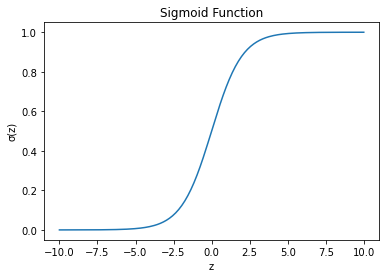

In [1]:

import numpy as np
import matplotlib.pyplot as plt

z = np.linspace(-10, 10, 200)
sigmoid = 1 / (1 + np.exp(-z))

plt.figure()
plt.plot(z, sigmoid)
plt.title("Sigmoid Function")
plt.xlabel("z")
plt.ylabel("σ(z)")
plt.show()


## 4. Import Required Libraries

In [2]:

import pandas as pd
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)


## 5. Load Dataset (Assignment Requirement)

This method must be used for the autograded assignment.

In [3]:

iris = load_iris()
X = iris.data
y = iris.target

df = pd.DataFrame(X, columns=iris.feature_names)
df['species'] = y
df.head()


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


## 6. Optional: Load Data from Local File or Web

### Local file
pd.read_csv('iris.csv')

### Web-based file
pd.read_csv(url)

These are for demonstration only.

## 7. Train-Test Split

In [4]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


## 8. Train Logistic Regression Model

In [5]:

model = LogisticRegression(max_iter=200)
model.fit(X_train, y_train)


LogisticRegression(C=1.0, class_weight=None, dual=False, fit_intercept=True,
                   intercept_scaling=1, l1_ratio=None, max_iter=200,
                   multi_class='auto', n_jobs=None, penalty='l2',
                   random_state=None, solver='lbfgs', tol=0.0001, verbose=0,
                   warm_start=False)

## 9. Make Predictions

In [6]:

y_pred = model.predict(X_test)


## 10. Accuracy

$$\text{Accuracy} = \frac{\text{Correct Predictions}}{\text{Total Predictions}}$$

In [7]:

accuracy = accuracy_score(y_test, y_pred)
accuracy


1.0

## 11. Confusion Matrix

Rows = Actual class
Columns = Predicted class

Diagonal values represent correct predictions.

In [8]:

cm = confusion_matrix(y_test, y_pred)
cm


array([[10,  0,  0],
       [ 0,  9,  0],
       [ 0,  0, 11]], dtype=int64)

## 12. Precision, Recall, and F1-Score

Precision: $\frac{TP}{TP + FP}$

Recall: $\frac{TP}{TP + FN}$

F1-score: $2 \times \frac{Precision \times Recall}{Precision + Recall}$

In [9]:

precision = precision_score(y_test, y_pred, average='macro')
recall = recall_score(y_test, y_pred, average='macro')
f1 = f1_score(y_test, y_pred, average='macro')

precision, recall, f1


(1.0, 1.0, 1.0)

## 13. Full Classification Report

In [10]:

print(classification_report(y_test, y_pred, target_names=iris.target_names))


              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



## 14. Summary and Discussion

- A model is a learned mathematical function
- Logistic Regression outputs probabilities
- Accuracy alone may not tell the full story
- Confusion matrix shows detailed performance
- Precision and Recall provide deeper evaluation insight

This notebook integrates theory, equations, visualization, and implementation for lecture use.